In [1]:
import pandas as pd
import yfinance as yf

In [2]:
calls = pd.read_csv("../data/options/SPY_Calls.csv")

In [3]:
spy = yf.Ticker("SPY")

spy_price = spy.history(period="1d")["Close"].iloc[-1]

print(f"Current SPY Price: {spy_price:.2f}")

Current SPY Price: 768.30


In [4]:
calls["Distance"] = abs(calls["strike"] - spy_price)

In [5]:
atm_option = calls.loc[calls["Distance"].idxmin()]

print(atm_option)

contractSymbol              SPY260806C00768000
lastTradeDate        2026-08-06 16:20:44+00:00
strike                                   768.0
lastPrice                                 1.17
bid                                       1.16
ask                                       1.17
change                                   -2.91
percentChange                        -71.32353
volume                                 62077.0
openInterest                              2282
impliedVolatility                     0.064218
inTheMoney                                True
contractSize                           REGULAR
currency                                   USD
Distance                              0.299988
Name: 61, dtype: object


In [6]:
print(atm_option[
    [
        "strike",
        "lastPrice",
        "bid",
        "ask",
        "volume",
        "openInterest",
        "impliedVolatility",
        "inTheMoney"
    ]
])

strike                  768.0
lastPrice                1.17
bid                      1.16
ask                      1.17
volume                62077.0
openInterest             2282
impliedVolatility    0.064218
inTheMoney               True
Name: 61, dtype: object


In [7]:
calls = calls.sort_values("strike")

In [8]:
calls[
    [
        "strike",
        "impliedVolatility",
        "inTheMoney"
    ]
].head(15)

,strike,impliedVolatility,inTheMoney
0,630.0,2.288090,True
1,675.0,1.583986,True
2,680.0,0.000010,True
3,685.0,1.439456,True
4,700.0,0.744143,True
5,710.0,0.662113,True
6,712.0,0.640629,True
7,713.0,0.613285,True
8,715.0,0.558598,True
9,716.0,0.599613,True


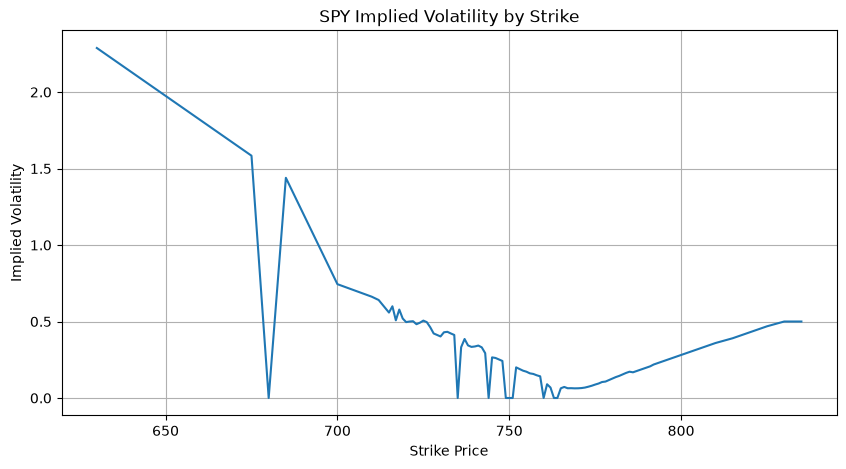

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    calls["strike"],
    calls["impliedVolatility"]
)

plt.title("SPY Implied Volatility by Strike")

plt.xlabel("Strike Price")

plt.ylabel("Implied Volatility")

plt.grid(True)

plt.show()

In [10]:
calls.to_csv(
    "../data/options/SPY_Calls_Filtered.csv",
    index=False
)